## Data Preprocessing

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"


### Data Wrangling and EDA


In [2]:
restaurants = pd.read_csv(
    "/Users/jw/Desktop/MIDS SP25/Machine Learning/Final Project/healthinspections_2024_withsvi.csv"
)
restaurants

,Unnamed: 0,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,ZCTA5
0,0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,...,2.0,0.1,0.1,0.1,0.1,3.4,0.8,0.5,0.3,90004.0
1,1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,...,2.1,0.1,0.1,0.8,0.6,5.5,1.5,0.6,0.3,90713.0
2,2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,...,1.5,0.1,0.1,0.1,0.1,3.2,1.0,0.8,0.5,90019.0
3,3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,...,2.5,0.9,0.5,0.0,0.1,4.5,1.0,1.8,0.8,90028.0
4,4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,...,2.6,0.4,0.4,0.2,0.2,4.7,1.4,0.6,0.5,91602.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52938,52938,2024-01-02,Subway #43833,7709 E BEN WHITE BLVD EB SVRD,AUSTIN,78744.0,Routine Inspection,91.0,NaN,Unit 104,...,0.9,0.2,0.1,0.1,0.1,2.7,0.7,0.0,0.1,78741.0
52939,52939,2024-01-02,ZZa Pizza + Salad,15511 W SH 71,BEE CAVE,78738.0,Routine Inspection,92.0,NaN,UNIT 150,...,3.1,0.1,0.1,0.0,0.2,2.3,1.0,0.1,0.1,78738.0
52940,52940,2024-01-02,International Food Market,11331 N LAMAR BLVD,AUSTIN,78753.0,Routine Inspection,89.0,NaN,Unit H,...,1.9,0.0,0.1,0.0,0.1,2.6,1.3,0.3,0.3,78753.0
52941,52941,2024-01-02,Jack in the Box #912,6540 ED BLUESTEIN SB BLVD,AUSTIN,78723.0,Routine Inspection,94.0,NaN,NaN,...,1.4,0.0,0.1,0.0,0.1,3.6,1.4,0.3,0.2,78723.0


In [3]:
restaurants = restaurants[
    [
        "INSPECTION_DATE",
        "SCORE",
        "GRADE",
        "STORE_NAME",
        "STREET_ADDRESS",
        "CITY",
        "ZIP5",
        "STATE",
        "EP_POV150",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "F_POV150",
        "SERVICE_DESCRIPTION",
    ]
]

In [4]:
restaurants["STATE"].value_counts()

STATE
CA    37643
KY     8523
TX     6777
Name: count, dtype: int64

In [5]:
restaurants.groupby("STATE")["SERVICE_DESCRIPTION"].value_counts()

STATE  SERVICE_DESCRIPTION       
CA     ROUTINE INSPECTION            37051
       OWNER INITIATED INSPECTION      592
KY     REGULAR                        7019
       FOLLOWUP                        686
       OTHER                           422
       COMPLAINT                       205
       SURVEY                          149
       OFFICE                           25
       ENFORCEMENT ACTIONS              15
       Education                         2
TX     Routine Inspection             6748
       Follow-Up Inspection             29
Name: count, dtype: int64

In [ ]:
serv_des = [
    "ROUTINE INSPECTION",
    "REGULAR",
    "Routune Inspection",
    "Follow-Up Inspection",
    "FOLLOWUP",
]
# Keep only rows where SERVICE_DESCRIPTION is in the list
restaurants = restaurants[restaurants["SERVICE_DESCRIPTION"].isin(serv_des)]

# standardize SERVICE_DESCRIPTION values
standardization_map = {
    "ROUTINE INSPECTION": "Routine Inspection",
    "REGULAR": "Routine Inspection",
    "Routune Inspection": "Routine Inspection", 
    "FOLLOW-UP INSPECTION": "Follow-Up Inspection",
    "FOLLOWUP": "Follow-Up Inspection"
}

restaurants["SERVICE_DESCRIPTION"] = restaurants["SERVICE_DESCRIPTION"].map(standardization_map)



### Census Data Wrangling 

In [7]:
census = pd.read_csv(
    "/Users/jw/Desktop/MIDS SP25/Machine Learning/Final Project/healthinspections_2024_censusindicators.csv"
)
census

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,INSPDATE_YEAR,...,Zip,Country,Source,geometry,PRIMARY_ZCTA,buffer,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,2024,...,90020.0,US,City of Los Angeles (CC0 1.0),POINT (-13168932.121192798 4038094.9968518936),90004.0,POLYGON ((-13165713.431192799 4038094.99685189...,64645.500000,2.320000,1755.800000,42499.700000
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,2024,...,90713.0,US,Los Angeles (Los Angeles County license to cop...,POINT (-13148707.930063948 4009888.0653141276),90713.0,POLYGON ((-13145489.240063949 4009888.06531412...,112001.714286,3.130000,2346.428571,37331.571429
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,2024,...,90019.0,US,City of Los Angeles (CC0 1.0),POINT (-13172079.123197524 4034756.0163900163),90019.0,POLYGON ((-13168860.433197524 4034756.01639001...,67153.000000,2.385556,1848.000000,41001.888889
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,2024,...,90028.0,US,City of Los Angeles (CC0 1.0),POINT (-13171547.01603153 4042482.1722482773),90028.0,POLYGON ((-13168328.32603153 4042482.172248277...,79224.375000,1.988750,1992.750000,38403.625000
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,2024,...,91602.0,US,City of Los Angeles (CC0 1.0),POINT (-13175841.721986335 4049232.9093501884),91602.0,POLYGON ((-13172623.031986335 4049232.90935018...,100588.428571,1.932500,2194.714286,27773.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52938,2024-01-02,Subway #43833,7709 E BEN WHITE BLVD EB SVRD,AUSTIN,78744.0,Routine Inspection,91.0,NaN,Unit 104,2024,...,78744.0,US,TIGER/Line® dataset from the US Census Bureau,POINT (-10874630.848093474 3531741.217826435),78741.0,POLYGON ((-10871412.158093475 3531741.21782643...,70385.000000,2.586000,1384.000000,25493.800000
52939,2024-01-02,ZZa Pizza + Salad,15511 W SH 71,BEE CAVE,78738.0,Routine Inspection,92.0,NaN,UNIT 150,2024,...,78738.0,US,City of Austin (Public Domain),POINT (-10907713.10832589 3544338.9375500926),78738.0,POLYGON ((-10904494.41832589 3544338.937550092...,149513.500000,2.390000,1922.500000,25440.500000
52940,2024-01-02,International Food Market,11331 N LAMAR BLVD,AUSTIN,78753.0,Routine Inspection,89.0,NaN,Unit H,2024,...,78753.0,US,City of Austin (Public Domain),POINT (-10874225.979105456 3552771.754906076),78753.0,POLYGON ((-10871007.289105456 3552771.75490607...,74772.333333,2.320000,1566.666667,46817.000000
52941,2024-01-02,Jack in the Box #912,6540 ED BLUESTEIN SB BLVD,AUSTIN,78723.0,Routine Inspection,94.0,NaN,NaN,2024,...,78723.0,US,TIGER/Line® dataset from the US Census Bureau,POINT (-10871589.154327037 3542717.569882022),78723.0,POLYGON ((-10868370.464327037 3542717.56988202...,88392.666667,2.450000,1658.333333,23473.666667


In [8]:
# subsetting for columns that we need in the census dataset
census = census[
    [
        "INSPECTION_DATE",
        "STORE_NAME",
        "STREET_ADDRESS",
        "CITY",
        "ZIP5",
        "STATE",
        "AVG_INCOME_NEARBY_ZCTAS",
        "AVG_HH_SIZE_NEARBY_ZCTAS",
        "AVG_RENT_NEARBY_ZCTAS",
        "AVG_POP_NEARBY_ZCTAS",
    ]
]

In [9]:
# merging the census data with the restaurant data
# merging on inspection date as one resturant can have multiple inspections
# and we want to keep all the inspections


restaurants_merged = pd.merge(
    census,
    restaurants,
    how="right",
    on=["INSPECTION_DATE", "STORE_NAME", "STREET_ADDRESS", "CITY", "ZIP5", "STATE"],
    indicator=True,
)
restaurants_merged

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,STATE,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,...,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_DESCRIPTION,_merge
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,CA,64645.500000,2.320000,1755.800000,42499.700000,...,21.3,79.4,51.8,0.2,18.5,16.9,1.6,0.0,ROUTINE INSPECTION,both
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,CA,112001.714286,3.130000,2346.428571,37331.571429,...,2.9,54.5,1.6,0.0,3.5,1.7,0.2,0.0,ROUTINE INSPECTION,both
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,CA,67153.000000,2.385556,1848.000000,41001.888889,...,17.2,82.5,25.5,0.2,12.3,13.2,2.4,0.0,ROUTINE INSPECTION,both
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,CA,79224.375000,1.988750,1992.750000,38403.625000,...,12.9,57.7,82.9,0.0,8.1,27.4,6.0,0.0,ROUTINE INSPECTION,both
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,CA,100588.428571,1.932500,2194.714286,27773.000000,...,2.9,40.6,55.2,0.4,3.6,4.7,0.0,0.0,ROUTINE INSPECTION,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62691,2024-02-12,Wing Daddy's Sauce House,9811 S IH 35 NB SVRD,AUSTIN,78744.0,TX,95172.200000,2.430000,1849.600000,38780.400000,...,10.2,77.9,23.3,6.8,6.7,5.1,0.1,0.0,Follow-Up Inspection,both
62692,2024-02-08,Las Lomas Mexican Restaurant,730 W STASSNEY LN,AUSTIN,78745.0,TX,86721.000000,2.140000,1642.000000,54223.333333,...,4.6,47.1,25.3,1.0,3.6,5.1,0.7,0.0,Follow-Up Inspection,both
62693,2024-02-07,Tulum Mexican Restaurant and Tequila Bar,3519 N FM 620 RD,AUSTIN,78734.0,TX,143876.333333,2.436667,1756.333333,19259.666667,...,2.0,23.8,6.0,4.7,1.1,1.8,0.8,0.0,Follow-Up Inspection,both
62694,2024-01-24,PF - Commercial Kitchen Factories Austin,16708 PICADILLY CT,PFLUGERVILLE,78664.0,TX,101426.000000,2.592500,1696.250000,66504.000000,...,4.6,57.7,20.3,0.1,4.0,2.7,0.7,0.0,Follow-Up Inspection,both


In [10]:
# checking for duplicates

# merging on store name, street address, city, and zip code is not a
# 1-1 merge as strip malls, big in CA, have multiple stores with the same
# address

duplicates = restaurants_merged.duplicated(
    subset=["INSPECTION_DATE", "STORE_NAME", "STREET_ADDRESS", "CITY", "ZIP5", "STATE"]
)
restaurants_merged[duplicates]

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,STATE,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,...,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_DESCRIPTION,_merge
31,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,CA,88993.200000,3.156000,1916.000000,44217.200000,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
32,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,CA,88993.200000,3.156000,1916.000000,44217.200000,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
33,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,CA,88993.200000,3.156000,1916.000000,44217.200000,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
34,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,CA,88993.200000,3.156000,1916.000000,44217.200000,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
35,2024-01-02,CARDENAS MARKET #20,1645 W HOLT AVE,POMONA,91768,CA,88993.200000,3.156000,1916.000000,44217.200000,...,15.1,87.1,15.1,7.1,17.1,6.0,13.4,0.0,ROUTINE INSPECTION,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62662,2024-09-19,MONETS MARKET,2204 DUNDEE RD,LOUISVILLE,40205.0,KY,75188.571429,2.050000,1124.428571,18556.500000,...,0.5,7.6,9.0,0.0,0.3,5.2,6.1,0.0,REGULAR,both
62663,2024-09-19,MONETS MARKET,2204 DUNDEE RD,LOUISVILLE,40205.0,KY,75188.571429,2.050000,1124.428571,18556.500000,...,0.5,7.6,9.0,0.0,0.3,5.2,6.1,0.0,REGULAR,both
62664,2024-09-19,MONETS MARKET,2204 DUNDEE RD,LOUISVILLE,40205.0,KY,75188.571429,2.050000,1124.428571,18556.500000,...,0.5,7.6,9.0,0.0,0.3,5.2,6.1,0.0,REGULAR,both
62671,2024-08-28,Tarka Indian Kitchen,2525 W ANDERSON LN,AUSTIN,78757.0,TX,86505.285714,2.071429,1548.285714,33927.285714,...,3.5,35.8,23.0,0.0,4.2,4.6,0.8,0.0,Follow-Up Inspection,both


In [11]:
# we will drop all observation that are missing svi data post merge
restaurants_merged = restaurants_merged[restaurants_merged["_merge"] == "both"]
restaurants_merged

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,STATE,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,...,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_DESCRIPTION,_merge
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,CA,64645.500000,2.320000,1755.800000,42499.700000,...,21.3,79.4,51.8,0.2,18.5,16.9,1.6,0.0,ROUTINE INSPECTION,both
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,CA,112001.714286,3.130000,2346.428571,37331.571429,...,2.9,54.5,1.6,0.0,3.5,1.7,0.2,0.0,ROUTINE INSPECTION,both
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,CA,67153.000000,2.385556,1848.000000,41001.888889,...,17.2,82.5,25.5,0.2,12.3,13.2,2.4,0.0,ROUTINE INSPECTION,both
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,CA,79224.375000,1.988750,1992.750000,38403.625000,...,12.9,57.7,82.9,0.0,8.1,27.4,6.0,0.0,ROUTINE INSPECTION,both
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,CA,100588.428571,1.932500,2194.714286,27773.000000,...,2.9,40.6,55.2,0.4,3.6,4.7,0.0,0.0,ROUTINE INSPECTION,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62691,2024-02-12,Wing Daddy's Sauce House,9811 S IH 35 NB SVRD,AUSTIN,78744.0,TX,95172.200000,2.430000,1849.600000,38780.400000,...,10.2,77.9,23.3,6.8,6.7,5.1,0.1,0.0,Follow-Up Inspection,both
62692,2024-02-08,Las Lomas Mexican Restaurant,730 W STASSNEY LN,AUSTIN,78745.0,TX,86721.000000,2.140000,1642.000000,54223.333333,...,4.6,47.1,25.3,1.0,3.6,5.1,0.7,0.0,Follow-Up Inspection,both
62693,2024-02-07,Tulum Mexican Restaurant and Tequila Bar,3519 N FM 620 RD,AUSTIN,78734.0,TX,143876.333333,2.436667,1756.333333,19259.666667,...,2.0,23.8,6.0,4.7,1.1,1.8,0.8,0.0,Follow-Up Inspection,both
62694,2024-01-24,PF - Commercial Kitchen Factories Austin,16708 PICADILLY CT,PFLUGERVILLE,78664.0,TX,101426.000000,2.592500,1696.250000,66504.000000,...,4.6,57.7,20.3,0.1,4.0,2.7,0.7,0.0,Follow-Up Inspection,both


In [12]:
#  we are checking for duplicates again to get an understanding of how many restaurants
# share the same address. it may be a unique charactersitic in our dataset
duplicates = restaurants_merged.duplicated(
    subset=["INSPECTION_DATE", "STORE_NAME", "STREET_ADDRESS", "CITY", "ZIP5", "STATE"]
)
restaurants_merged[duplicates]

print(
    "Number of duplicates:",
    len(restaurants_merged[duplicates]),
    "\nPercentage of dataset that is duplicates: {:.2f}%".format(
        len(restaurants_merged[duplicates]) / len(restaurants_merged) * 100
    ),
)

Number of duplicates: 21011 
Percentage of dataset that is duplicates: 41.49%


### Variable Manipulation

In [13]:
# creating a dummy variable for service
restaurants_merged["SERVICE_DESCRIPTION"].value_counts()
restaurants_merged = pd.get_dummies(
    restaurants_merged,
    columns=["SERVICE_DESCRIPTION"],
    prefix="SERVICE",
    drop_first=False,
)

restaurants_merged

,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,STATE,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,...,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,_merge,SERVICE_FOLLOWUP,SERVICE_Follow-Up Inspection,SERVICE_REGULAR,SERVICE_ROUTINE INSPECTION
0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,CA,64645.500000,2.320000,1755.800000,42499.700000,...,0.2,18.5,16.9,1.6,0.0,both,False,False,False,True
1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,CA,112001.714286,3.130000,2346.428571,37331.571429,...,0.0,3.5,1.7,0.2,0.0,both,False,False,False,True
2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,CA,67153.000000,2.385556,1848.000000,41001.888889,...,0.2,12.3,13.2,2.4,0.0,both,False,False,False,True
3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,CA,79224.375000,1.988750,1992.750000,38403.625000,...,0.0,8.1,27.4,6.0,0.0,both,False,False,False,True
4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,CA,100588.428571,1.932500,2194.714286,27773.000000,...,0.4,3.6,4.7,0.0,0.0,both,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62691,2024-02-12,Wing Daddy's Sauce House,9811 S IH 35 NB SVRD,AUSTIN,78744.0,TX,95172.200000,2.430000,1849.600000,38780.400000,...,6.8,6.7,5.1,0.1,0.0,both,False,True,False,False
62692,2024-02-08,Las Lomas Mexican Restaurant,730 W STASSNEY LN,AUSTIN,78745.0,TX,86721.000000,2.140000,1642.000000,54223.333333,...,1.0,3.6,5.1,0.7,0.0,both,False,True,False,False
62693,2024-02-07,Tulum Mexican Restaurant and Tequila Bar,3519 N FM 620 RD,AUSTIN,78734.0,TX,143876.333333,2.436667,1756.333333,19259.666667,...,4.7,1.1,1.8,0.8,0.0,both,False,True,False,False
62694,2024-01-24,PF - Commercial Kitchen Factories Austin,16708 PICADILLY CT,PFLUGERVILLE,78664.0,TX,101426.000000,2.592500,1696.250000,66504.000000,...,0.1,4.0,2.7,0.7,0.0,both,False,True,False,False


In [14]:
# encoding datetime information and dropping the original column
restaurants_merged["INSPECTION_DATE"] = restaurants_merged["INSPECTION_DATE"].astype(
    "datetime64[ns]"
)
restaurants_merged["INSPDATE_MONTH"] = restaurants_merged["INSPECTION_DATE"].dt.month
restaurants_merged["INSPDATE_DAY"] = restaurants_merged["INSPECTION_DATE"].dt.day
restaurants_merged = restaurants_merged.drop(["INSPECTION_DATE"], axis=1)
restaurants_merged

,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,STATE,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,...,EP_NOVEH,EP_GROUPQ,F_POV150,_merge,SERVICE_FOLLOWUP,SERVICE_Follow-Up Inspection,SERVICE_REGULAR,SERVICE_ROUTINE INSPECTION,INSPDATE_MONTH,INSPDATE_DAY
0,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,CA,64645.500000,2.320000,1755.800000,42499.700000,90.0,...,16.9,1.6,0.0,both,False,False,False,True,1,2
1,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,CA,112001.714286,3.130000,2346.428571,37331.571429,97.0,...,1.7,0.2,0.0,both,False,False,False,True,1,2
2,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,CA,67153.000000,2.385556,1848.000000,41001.888889,96.0,...,13.2,2.4,0.0,both,False,False,False,True,1,2
3,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,CA,79224.375000,1.988750,1992.750000,38403.625000,94.0,...,27.4,6.0,0.0,both,False,False,False,True,1,2
4,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,CA,100588.428571,1.932500,2194.714286,27773.000000,92.0,...,4.7,0.0,0.0,both,False,False,False,True,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62691,Wing Daddy's Sauce House,9811 S IH 35 NB SVRD,AUSTIN,78744.0,TX,95172.200000,2.430000,1849.600000,38780.400000,71.0,...,5.1,0.1,0.0,both,False,True,False,False,2,12
62692,Las Lomas Mexican Restaurant,730 W STASSNEY LN,AUSTIN,78745.0,TX,86721.000000,2.140000,1642.000000,54223.333333,84.0,...,5.1,0.7,0.0,both,False,True,False,False,2,8
62693,Tulum Mexican Restaurant and Tequila Bar,3519 N FM 620 RD,AUSTIN,78734.0,TX,143876.333333,2.436667,1756.333333,19259.666667,88.0,...,1.8,0.8,0.0,both,False,True,False,False,2,7
62694,PF - Commercial Kitchen Factories Austin,16708 PICADILLY CT,PFLUGERVILLE,78664.0,TX,101426.000000,2.592500,1696.250000,66504.000000,100.0,...,2.7,0.7,0.0,both,False,True,False,False,1,24


### Data Cleaning and Variable Deletion 

In [15]:
# dropping rows with NAN values
restaurants_merged = restaurants_merged.dropna()

# returning any rows with NAN values
assert (
    len(restaurants_merged[restaurants_merged.isna().any(axis=1)]) == 0
), "There are still rows with NAN values in the dataset"

In [16]:
# dropping any rows where a variable has -999 in it
restaurants_merged = restaurants_merged[(restaurants_merged != -999).all(axis=1)]

# dropping the _merge column
restaurants_merged = restaurants_merged.drop(columns=["_merge"])
restaurants_merged

# dropping the columns that are not needed
restaurants_merged = restaurants_merged.drop(
    columns=["STORE_NAME", "STREET_ADDRESS", "CITY", "ZIP5"]
)

### Removing subset of test data for our experiment 

#### Experiment for external validity 

In [17]:
# filter rows where the condition is true
states = ["KY", "TX"]
condition = restaurants_merged["STATE"].isin(states)
test_experiment2 = restaurants_merged[condition]

# drop those sampled rows from the original DataFrame
restaurants_merged = restaurants_merged.drop(test_experiment2.index)

test_experiment2

,STATE,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,GRADE,EP_POV150,EP_UNEMP,EP_HBURD,...,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_FOLLOWUP,SERVICE_Follow-Up Inspection,SERVICE_REGULAR,SERVICE_ROUTINE INSPECTION,INSPDATE_MONTH,INSPDATE_DAY
52990,KY,74309.200000,1.976000,1112.800000,17266.800000,100.0,A,11.6,2.7,18.1,...,0.3,5.2,6.1,0.0,False,False,True,False,8,21
52991,KY,94620.500000,2.372500,1396.500000,29074.500000,100.0,A,10.1,6.2,27.5,...,0.0,13.6,0.8,0.0,False,False,True,False,3,28
52992,KY,85205.500000,1.870000,1141.800000,14673.666667,100.0,A,16.6,4.4,26.7,...,1.0,7.3,3.0,0.0,False,False,True,False,5,13
52993,KY,85205.500000,1.870000,1141.800000,14673.666667,100.0,A,16.6,4.4,26.7,...,1.0,7.3,3.0,0.0,False,False,True,False,5,13
52994,KY,74309.200000,1.976000,1112.800000,17266.800000,100.0,A,11.6,2.7,18.1,...,0.3,5.2,6.1,0.0,False,False,True,False,3,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62647,KY,80919.000000,2.493333,1273.666667,33907.000000,100.0,A,13.7,4.3,21.9,...,0.6,3.5,0.1,0.0,False,False,True,False,9,16
62652,KY,82106.166667,2.238333,1288.833333,23943.833333,93.0,C,8.1,3.9,19.5,...,1.4,3.1,0.8,0.0,False,False,True,False,7,19
62653,KY,82106.166667,2.238333,1288.833333,23943.833333,93.0,C,8.1,3.9,19.5,...,1.4,3.1,0.8,0.0,False,False,True,False,7,19
62661,KY,75188.571429,2.050000,1124.428571,18556.500000,98.0,A,11.6,2.7,18.1,...,0.3,5.2,6.1,0.0,False,False,True,False,9,19


#### Experiment for Subgroup Analysis

In [18]:
# filter rows where the condition is true
condition = restaurants_merged["F_POV150"] == 1
filtered_df = restaurants_merged[condition]

# sample 20% of those rows
test_experiment3 = filtered_df.sample(frac=0.2, random_state=42)

test_experiment3

,STATE,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,GRADE,EP_POV150,EP_UNEMP,EP_HBURD,...,EP_CROWD,EP_NOVEH,EP_GROUPQ,F_POV150,SERVICE_FOLLOWUP,SERVICE_Follow-Up Inspection,SERVICE_REGULAR,SERVICE_ROUTINE INSPECTION,INSPDATE_MONTH,INSPDATE_DAY
49338,CA,47290.909091,2.510909,1521.000000,27398.615385,98.0,A,54.6,13.3,57.8,...,16.4,52.9,9.4,1.0,False,False,False,True,11,21
34784,CA,51871.214286,2.519286,1557.214286,34581.000000,98.0,A,85.9,49.7,100.0,...,0.0,100.0,97.4,1.0,False,False,False,True,8,13
24729,CA,52357.625000,2.822222,1520.625000,42136.888889,99.0,A,52.4,12.5,55.1,...,19.6,27.7,12.6,1.0,False,False,False,True,4,30
52729,CA,56735.846154,2.124615,1752.538462,30650.733333,99.0,A,43.2,6.7,52.9,...,34.4,35.7,3.0,1.0,False,False,False,True,12,24
18941,CA,51082.923077,2.483077,1562.615385,34427.666667,98.0,A,43.2,11.6,42.3,...,14.1,50.2,8.2,1.0,False,False,False,True,4,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16703,CA,56127.333333,2.967143,1630.833333,45841.142857,99.0,A,41.2,8.0,48.1,...,24.7,18.5,2.2,1.0,False,False,False,True,3,26
40336,CA,56127.333333,2.967143,1630.833333,45841.142857,96.0,A,41.2,8.0,48.1,...,24.7,18.5,2.2,1.0,False,False,False,True,9,7
52901,CA,50785.384615,2.363077,1580.615385,34036.933333,100.0,A,85.9,49.7,100.0,...,0.0,100.0,97.4,1.0,False,False,False,True,12,29
16491,CA,55372.250000,3.141111,1590.875000,54272.777778,95.0,A,41.2,8.0,48.1,...,24.7,18.5,2.2,1.0,False,False,False,True,3,23


In [19]:
# drop those sampled rows from the original DataFrame
restaurants_cleaned = restaurants_merged.drop(test_experiment3.index)

# dropping F_POV150 since it would be likely collinear with the other variables
restaurants_cleaned = restaurants_cleaned.drop(columns=["F_POV150", "STATE"])

restaurants_cleaned

,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,GRADE,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,...,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,SERVICE_FOLLOWUP,SERVICE_Follow-Up Inspection,SERVICE_REGULAR,SERVICE_ROUTINE INSPECTION,INSPDATE_MONTH,INSPDATE_DAY
0,64645.500000,2.320000,1755.800000,42499.700000,90.0,A,31.9,7.4,48.8,22.9,...,0.2,18.5,16.9,1.6,False,False,False,True,1,2
1,112001.714286,3.130000,2346.428571,37331.571429,97.0,A,7.9,5.6,16.5,8.0,...,0.0,3.5,1.7,0.2,False,False,False,True,1,2
2,67153.000000,2.385556,1848.000000,41001.888889,96.0,A,28.0,8.5,41.3,21.6,...,0.2,12.3,13.2,2.4,False,False,False,True,1,2
3,79224.375000,1.988750,1992.750000,38403.625000,94.0,A,31.3,10.3,46.8,10.1,...,0.0,8.1,27.4,6.0,False,False,False,True,1,2
4,100588.428571,1.932500,2194.714286,27773.000000,92.0,A,13.3,7.8,34.3,4.8,...,0.4,3.6,4.7,0.0,False,False,False,True,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52985,151582.250000,2.315000,2920.500000,26645.750000,73.0,C,6.9,5.4,17.6,1.7,...,0.0,1.8,2.2,0.2,False,False,False,True,12,31
52986,77895.700000,3.254000,1728.000000,38888.100000,95.0,A,21.4,4.9,36.7,22.4,...,5.6,14.6,6.3,1.4,False,False,False,True,12,31
52987,79197.166667,3.540000,1740.500000,60368.833333,91.0,A,25.3,7.8,38.9,41.1,...,1.5,21.9,8.1,0.1,False,False,False,True,12,31
52988,66198.500000,3.300000,1553.900000,51712.500000,95.0,A,40.2,10.3,51.5,36.2,...,0.4,18.2,16.6,0.7,False,False,False,True,12,31


### Plot the distribution for all variables

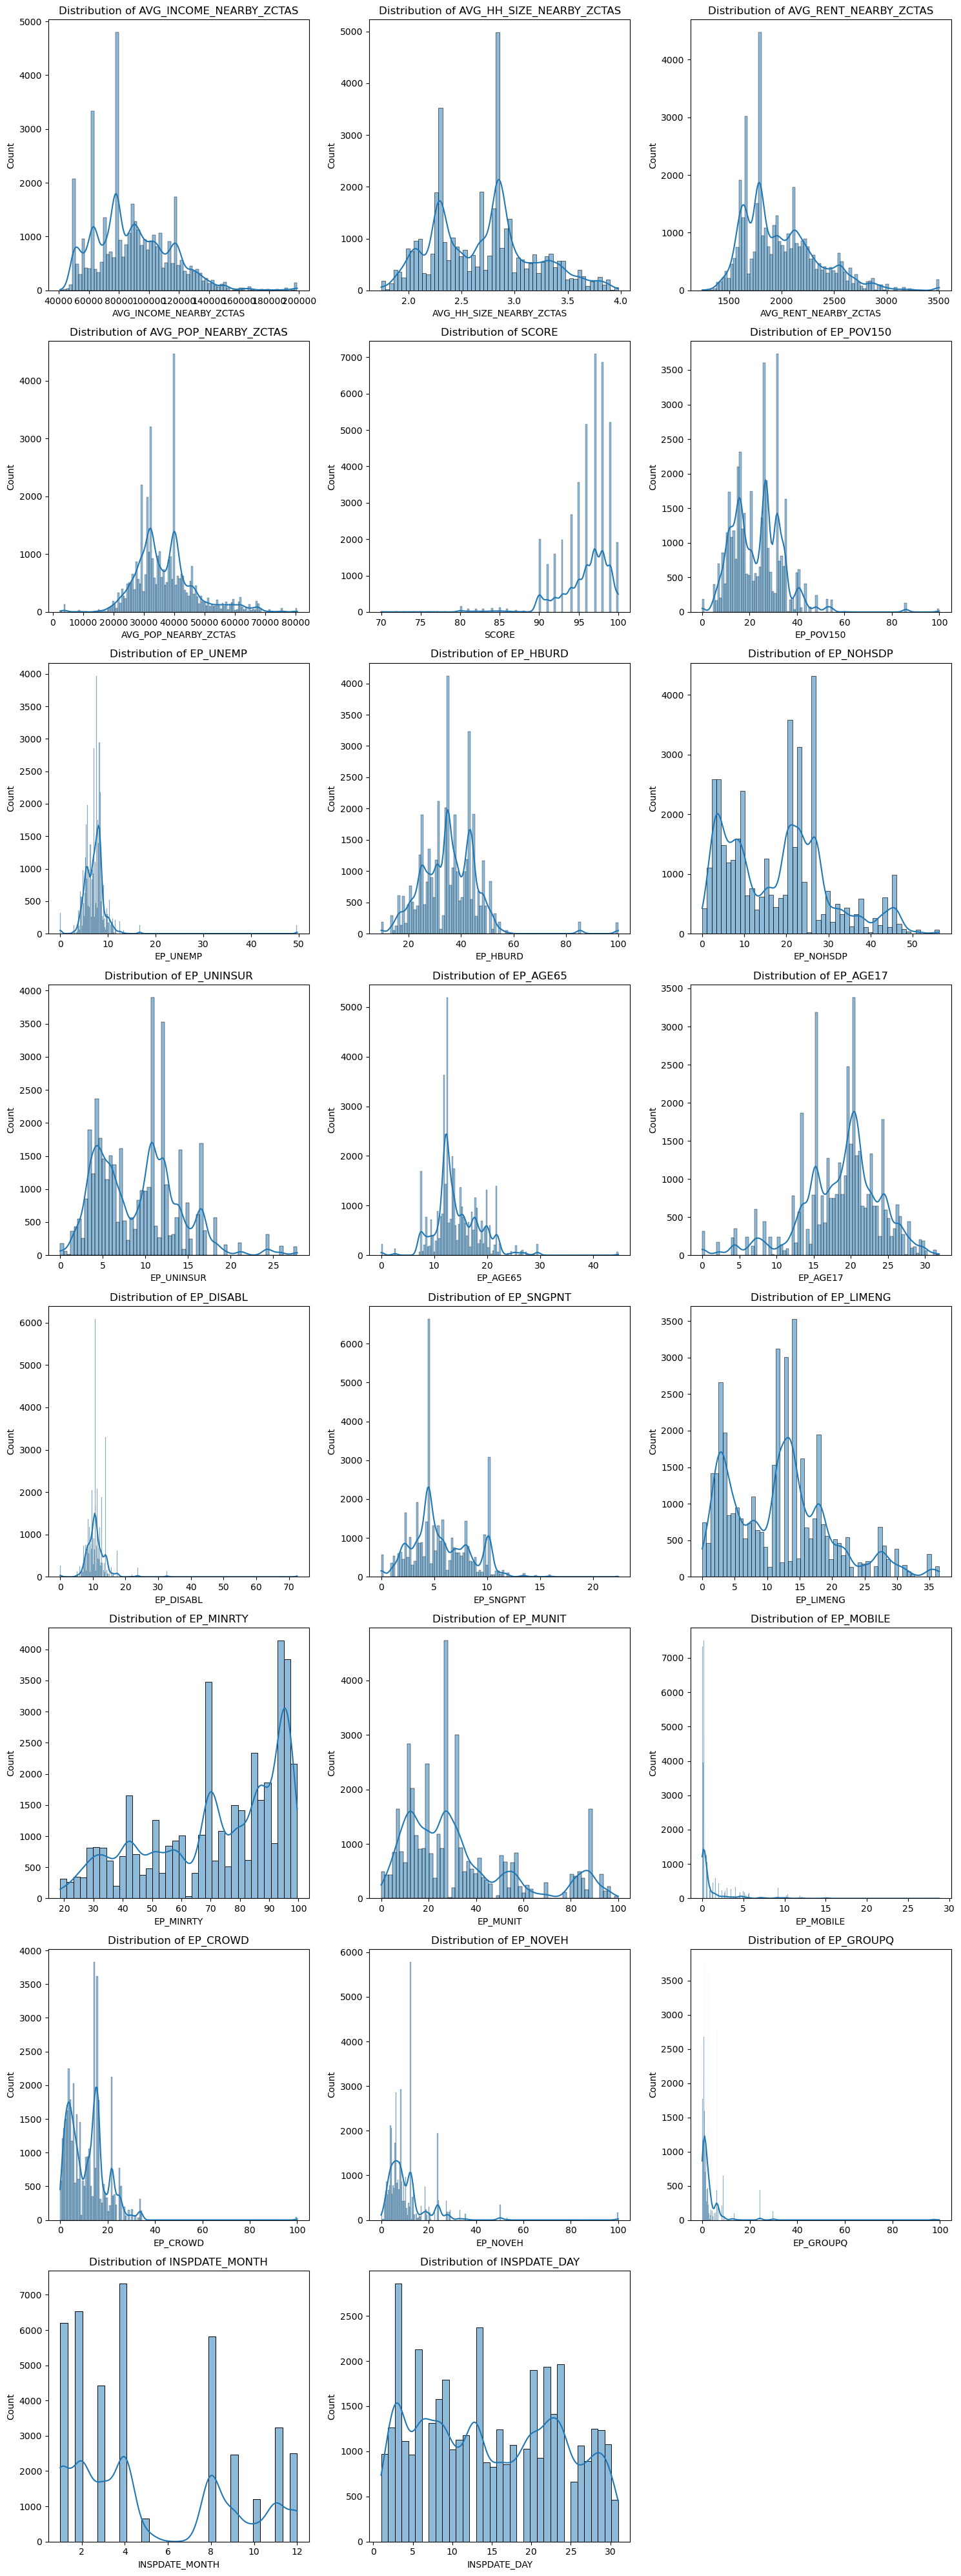

In [20]:
# Plot the distribution for all variables in a grid
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = restaurants_cleaned.select_dtypes(include="number").columns

# Set up the grid size
num_plots = len(numeric_cols)
cols = 3
rows = (num_plots // cols) + (num_plots % cols > 0)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(restaurants_cleaned[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [21]:
restaurants_cleaned[numeric_cols].skew().sort_values(ascending=False)

EP_GROUPQ                   9.799754
EP_UNEMP                    8.762533
EP_DISABL                   8.467269
EP_NOVEH                    4.283863
EP_MOBILE                   3.548924
EP_CROWD                    1.822787
EP_POV150                   1.212352
EP_HBURD                    1.179809
EP_MUNIT                    1.146899
AVG_RENT_NEARBY_ZCTAS       0.988654
EP_AGE65                    0.911125
AVG_POP_NEARBY_ZCTAS        0.847560
AVG_INCOME_NEARBY_ZCTAS     0.733753
EP_UNINSUR                  0.636736
EP_LIMENG                   0.631832
EP_SNGPNT                   0.552025
EP_NOHSDP                   0.527083
INSPDATE_MONTH              0.512281
AVG_HH_SIZE_NEARBY_ZCTAS    0.316971
INSPDATE_DAY                0.109828
EP_MINRTY                  -0.613512
EP_AGE17                   -0.737499
SCORE                      -2.097639
dtype: float64

In [22]:
# log transform the skewed variables
# List of skewed variables you want to transform
log_vars = [
    "EP_GROUPQ",
    "EP_UNEMP",
    "EP_DISABL",
    "EP_NOVEH",
    "EP_MOBILE",
    "EP_CROWD",
    "EP_POV150",
    "EP_HBURD",
    "EP_MUNIT",
]

# Apply log1p to each (handles zeros safely)
for var in log_vars:
    restaurants_cleaned[f"LOG_{var}"] = np.log1p(restaurants_cleaned[var])

### Subsetting for two training datasets (scores and grades)

Ask team about whether we want to include the adjunct race variables on the last page.

In [23]:
# creating training dataset from subset of restaurants dataset (using scores)
CA_restaurant_model_scores = restaurants_cleaned.drop(columns=["GRADE"])
CA_restaurant_model_scores

,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,SCORE,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,...,INSPDATE_DAY,LOG_EP_GROUPQ,LOG_EP_UNEMP,LOG_EP_DISABL,LOG_EP_NOVEH,LOG_EP_MOBILE,LOG_EP_CROWD,LOG_EP_POV150,LOG_EP_HBURD,LOG_EP_MUNIT
0,64645.500000,2.320000,1755.800000,42499.700000,90.0,31.9,7.4,48.8,22.9,15.5,...,2,0.955511,2.128232,2.251292,2.884801,0.182322,2.970414,3.493473,3.908015,3.966511
1,112001.714286,3.130000,2346.428571,37331.571429,97.0,7.9,5.6,16.5,8.0,3.0,...,2,0.182322,1.887070,2.341806,0.993252,0.000000,1.504077,2.186051,2.862201,0.955511
2,67153.000000,2.385556,1848.000000,41001.888889,96.0,28.0,8.5,41.3,21.6,15.0,...,2,1.223775,2.251292,2.341806,2.653242,0.182322,2.587764,3.367296,3.744787,3.277145
3,79224.375000,1.988750,1992.750000,38403.625000,94.0,31.3,10.3,46.8,10.1,12.6,...,2,1.945910,2.424803,2.701361,3.346389,0.000000,2.208274,3.475067,3.867026,4.429626
4,100588.428571,1.932500,2194.714286,27773.000000,92.0,13.3,7.8,34.3,4.8,5.6,...,2,0.000000,2.174752,2.174752,1.740466,0.336472,1.526056,2.660260,3.563883,4.028917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52985,151582.250000,2.315000,2920.500000,26645.750000,73.0,6.9,5.4,17.6,1.7,1.9,...,31,0.182322,1.856298,2.174752,1.163151,0.000000,1.029619,2.066863,2.923162,2.970414
52986,77895.700000,3.254000,1728.000000,38888.100000,95.0,21.4,4.9,36.7,22.4,11.0,...,31,0.875469,1.774952,2.517696,1.987874,1.887070,2.747271,3.109061,3.629660,3.242592
52987,79197.166667,3.540000,1740.500000,60368.833333,91.0,25.3,7.8,38.9,41.1,13.7,...,31,0.095310,2.174752,2.282382,2.208274,0.916291,3.131137,3.269569,3.686376,2.332144
52988,66198.500000,3.300000,1553.900000,51712.500000,95.0,40.2,10.3,51.5,36.2,13.7,...,31,0.530628,2.424803,2.624669,2.867899,0.336472,2.954910,3.718438,3.960813,2.821379


In [24]:
# creating training dataset from subset of restaurants dataset (using grades)
CA_restaurant_model_grades = restaurants_cleaned = restaurants_cleaned.drop(
    columns=["SCORE"]
)
CA_restaurant_model_grades

,AVG_INCOME_NEARBY_ZCTAS,AVG_HH_SIZE_NEARBY_ZCTAS,AVG_RENT_NEARBY_ZCTAS,AVG_POP_NEARBY_ZCTAS,GRADE,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,...,INSPDATE_DAY,LOG_EP_GROUPQ,LOG_EP_UNEMP,LOG_EP_DISABL,LOG_EP_NOVEH,LOG_EP_MOBILE,LOG_EP_CROWD,LOG_EP_POV150,LOG_EP_HBURD,LOG_EP_MUNIT
0,64645.500000,2.320000,1755.800000,42499.700000,A,31.9,7.4,48.8,22.9,15.5,...,2,0.955511,2.128232,2.251292,2.884801,0.182322,2.970414,3.493473,3.908015,3.966511
1,112001.714286,3.130000,2346.428571,37331.571429,A,7.9,5.6,16.5,8.0,3.0,...,2,0.182322,1.887070,2.341806,0.993252,0.000000,1.504077,2.186051,2.862201,0.955511
2,67153.000000,2.385556,1848.000000,41001.888889,A,28.0,8.5,41.3,21.6,15.0,...,2,1.223775,2.251292,2.341806,2.653242,0.182322,2.587764,3.367296,3.744787,3.277145
3,79224.375000,1.988750,1992.750000,38403.625000,A,31.3,10.3,46.8,10.1,12.6,...,2,1.945910,2.424803,2.701361,3.346389,0.000000,2.208274,3.475067,3.867026,4.429626
4,100588.428571,1.932500,2194.714286,27773.000000,A,13.3,7.8,34.3,4.8,5.6,...,2,0.000000,2.174752,2.174752,1.740466,0.336472,1.526056,2.660260,3.563883,4.028917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52985,151582.250000,2.315000,2920.500000,26645.750000,C,6.9,5.4,17.6,1.7,1.9,...,31,0.182322,1.856298,2.174752,1.163151,0.000000,1.029619,2.066863,2.923162,2.970414
52986,77895.700000,3.254000,1728.000000,38888.100000,A,21.4,4.9,36.7,22.4,11.0,...,31,0.875469,1.774952,2.517696,1.987874,1.887070,2.747271,3.109061,3.629660,3.242592
52987,79197.166667,3.540000,1740.500000,60368.833333,A,25.3,7.8,38.9,41.1,13.7,...,31,0.095310,2.174752,2.282382,2.208274,0.916291,3.131137,3.269569,3.686376,2.332144
52988,66198.500000,3.300000,1553.900000,51712.500000,A,40.2,10.3,51.5,36.2,13.7,...,31,0.530628,2.424803,2.624669,2.867899,0.336472,2.954910,3.718438,3.960813,2.821379


## Train/test split for SCORE and GRADE dataset

## Model 1: Linear Regression (using SCORE as our target)

In [25]:
# for the SCORE dataset (regression models)
from sklearn.model_selection import train_test_split

X_score = CA_restaurant_model_scores[
    [i for i in list(CA_restaurant_model_scores.columns) if i != "SCORE"]
]
y_score = CA_restaurant_model_scores[["SCORE"]]

# splitting into train, validation, test (70/15/15)
X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score, y_score, test_size=0.3, random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train_score)
X_test_scaled = scaler.transform(X_test_score)

In [27]:
# standard scaling? probably not feature selection...
from sklearn.preprocessing import StandardScaler

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_curve,
)

# regression model
linear_model = LinearRegression().fit(X_train_scaled, y_train_score)

In [29]:
# predicting target for the test set
y_pred_lin = linear_model.predict(X_test_scaled)

In [30]:
# MSE = measures the average of the squares of the errors/deviation
print("Mean Squared Error:", mean_squared_error(y_test_score, y_pred_lin))
# r2 = proportion of the variance for a dependent variable that is explained by the IVs
print("R-squared:", r2_score(y_test_score, y_pred_lin))

Mean Squared Error: 11.101032129055202
R-squared: 0.06682884671231004


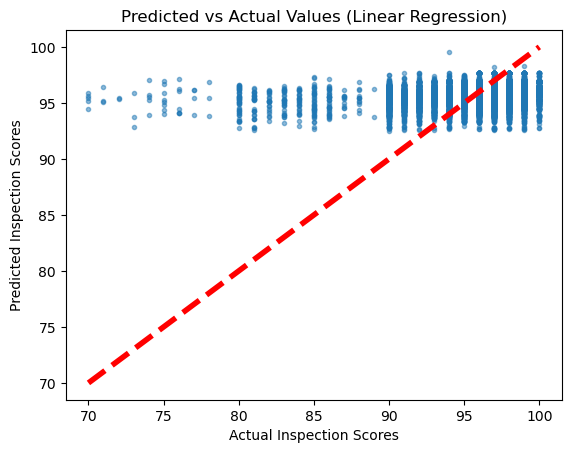

In [31]:
import matplotlib.pyplot as plt

# Plotting predicted vs. actual values
plt.scatter(y_test_score, y_pred_lin, marker=".", alpha=0.5)
plt.xlabel("Actual Inspection Scores")
plt.ylabel("Predicted Inspection Scores")
plt.title("Predicted vs Actual Values (Linear Regression)")
plt.plot(
    [y_test_score.min(), y_test_score.max()],
    [y_test_score.min(), y_test_score.max()],
    "r--",
    lw=4,
)
plt.show()

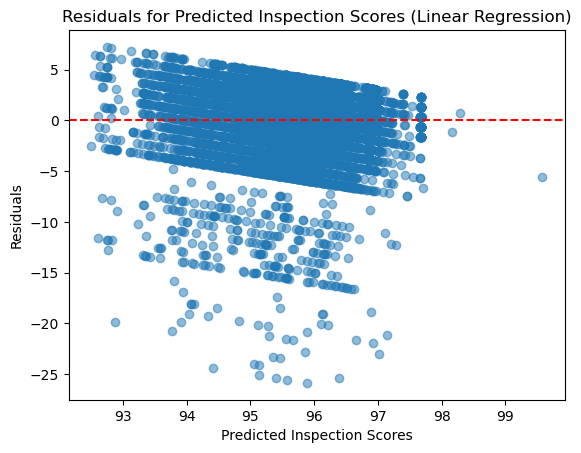

In [32]:
# Plotting residuals (difference between predicted and observed values)
residuals = y_test_score - y_pred_lin
plt.scatter(y_pred_lin, residuals, alpha=0.5)
plt.xlabel("Predicted Inspection Scores")
plt.ylabel("Residuals")
plt.title("Residuals for Predicted Inspection Scores (Linear Regression)")
plt.axhline(y=0, color="red", linestyle="--")
plt.show()

# Model 2: Random Forest (using SCORE as our target)

In [33]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = CA_restaurant_model_scores
X = data.drop("SCORE", axis=1)  # Features
y = data[["SCORE"]]  # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,  # number of trees
    max_depth=None,  # expand until leaves are pure or contain min_samples_split samples
    random_state=42,
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error: 9.7611
R² Score: 0.1917


# Model 3: XGBoost

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load your data
data = CA_restaurant_model_scores

# Define features and target
X = data.drop("SCORE", axis=1)
y = data["SCORE"]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Set up the parameter grid to search
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [3, 5],
}

# Initialize the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring="r2",  # optimize for R² score
    n_jobs=-1,  # use all CPU cores
    verbose=2,
)

# Run the grid search
grid_search.fit(X_train, y_train)

# Get the best model
best_gbr = grid_search.best_estimator_

# Predict on the test set
y_pred = best_gbr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.3s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.5s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  11.1s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   5.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=10

# Model 4: Lasso Regression

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# split into train (70%) and temp (30%)
X = CA_restaurant_model_scores.drop(columns=["SCORE"])
y = CA_restaurant_model_scores["SCORE"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# create pipeline with StandardScaler + Lasso
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=42))

# train on training set
lasso.fit(X_train, y_train)

# validate on validation set
y_val_pred = lasso.predict(X_val)
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Validation MSE: {val_mse:.2f}")
print(f"Validation R^2: {val_r2:.3f}")

# final evaluation on test set
y_test_pred = lasso.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test MSE: {test_mse:.2f}")
print(f"Test R^2: {test_r2:.3f}")

Validation MSE: 10.96
Validation R^2: 0.065
Test MSE: 11.29
Test R^2: 0.064


In [42]:
from sklearn.linear_model import Lasso

best_alpha = None
best_score = float("-inf")

for alpha in [0.001, 0.01, 0.1, 1, 10]:
    model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, random_state=42))
    model.fit(X_train, y_train)
    score = model.score(X_val, y_val)
    if score > best_score:
        best_score = score
        best_alpha = alpha

print(f"Best alpha based on validation set: {best_alpha}")

Best alpha based on validation set: 0.001


# Model 5: SVR 

In [43]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load your data
data = CA_restaurant_model_scores

# Define features and target
X = data.drop("SCORE", axis=1)
y = data["SCORE"]

# Important: Scale the features for SVR!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Set up hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10],
    "epsilon": [0.1, 0.2, 0.5],
    "kernel": ["linear", "rbf"],
}

# Initialize the SVR model
svr = SVR()

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring="r2",  # optimize for R² score
    n_jobs=-1,
    verbose=2,
)

# Run the grid search
grid_search.fit(X_train, y_train)

# Get the best model
best_svr = grid_search.best_estimator_

# Predict on the test set
y_pred = best_svr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=  32.7s
[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=  32.9s
[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=  32.8s
[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=  33.0s
[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=  33.1s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=  49.6s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=  49.5s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=  50.5s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=  51.7s
[CV] END .....................C=0.1, epsilon=0.1, kernel=rbf; total time=  54.7s
[CV] END ..................C=0.1, epsilon=0.2, kernel=linear; total time=  24.1s
[CV] END ..................C=0.1, epsilon=0.2, k